# Presentation Figures
## Lock Maintenance Prioritization — U.S. Inland Waterway System
**Team A02** | Generates all figures for the final slide deck.  
Figures save to `figures/presentation/`.

In [ ]:
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path
warnings.filterwarnings('ignore')

projectDir = Path.cwd()
dataDir = projectDir / 'Data'
stoppageDir = dataDir / 'stoppages'
figDir = projectDir / 'figures' / 'presentation'
figDir.mkdir(parents=True, exist_ok=True)

# pastel palette
PBLUE   = '#a8c8e8'
PRED    = '#f4a6a0'
PGREEN  = '#a8d8b0'
PYELLOW = '#f9e0a0'
PGRAY   = '#d8d8d8'
BLACK   = '#1a1a1a'
WHITE   = '#ffffff'
DRED    = '#e05a50'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelcolor': BLACK,
    'xtick.color': BLACK,
    'ytick.color': BLACK,
})

print('setup complete — figures save to', figDir)

## Load and clean data

In [2]:
# load stoppage data
allRecords = []
for f in sorted(stoppageDir.glob('*.json')):
    with open(f) as fh:
        allRecords.extend(json.load(fh))
rawDf = pd.DataFrame(allRecords).drop_duplicates()
stopDf = rawDf[rawDf['riverCode'].isin(['MI', 'IL'])].copy()

def parseDate(s):
    try:
        datePart = s.strip().split(' ')[0]
        parts = datePart.split('/')
        if len(parts) == 3 and int(parts[2]) < 2000:
            parts[2] = str(2000 + int(parts[2][-2:]))
        return pd.to_datetime('/'.join(parts), format='%m/%d/%Y', errors='coerce')
    except:
        return pd.NaT

stopDf['beginDt'] = stopDf['beginStopDate'].apply(parseDate)
stopDf['endDt'] = stopDf['endStopDate'].apply(parseDate)
stopDf['durationHrs'] = (stopDf['endDt'] - stopDf['beginDt']).dt.total_seconds() / 3600
stopDf['year'] = stopDf['beginDt'].dt.year
stopDf = stopDf[
    (stopDf['durationHrs'] > 0) &
    (stopDf['durationHrs'] < 8760) &
    (stopDf['year'].between(2021, 2023))
].copy()

unschedDf = stopDf[
    (stopDf['isScheduled'] == 'No') &
    (stopDf['trafficStopped'] == 'Y')
].copy()

infraReasons = [
    'Repairing lock or lock hardware',
    'Lock hardware or equipment malfunction',
    'Maintaining lock or lock equipment',
]
unschedDf['causeType'] = unschedDf['reasonCode'].apply(
    lambda r: 'infrastructure' if r in infraReasons else 'external'
)

infraHrs = unschedDf[unschedDf['causeType'] == 'infrastructure']['durationHrs'].sum()
totalHrs = unschedDf['durationHrs'].sum()
print(f'unscheduled traffic-stopping events: {len(unschedDf)}')
print(f'  infrastructure: {(unschedDf["causeType"]=="infrastructure").sum()} events, {infraHrs:.0f} hrs ({infraHrs/totalHrs*100:.0f}%)')
print(f'  external: {(unschedDf["causeType"]=="external").sum()} events, {totalHrs-infraHrs:.0f} hrs ({(totalHrs-infraHrs)/totalHrs*100:.0f}%)')

unscheduled traffic-stopping events: 84
  infrastructure: 7 events, 192 hrs (5%)
  external: 77 events, 3600 hrs (95%)


In [ ]:
# load GTR rates and volumes, merge
ratesRaw = pd.read_excel(dataDir / 'GTRFigure10Table9.xlsx', sheet_name='TWK', header=0)
ratesDf = ratesRaw[['DATE', 'ILL']].copy()
ratesDf.columns = ['date', 'illRate']
ratesDf['date'] = pd.to_datetime(ratesDf['date'], errors='coerce')
ratesDf = ratesDf[ratesDf['date'].notna() & (ratesDf['date'] >= '2010-01-01')].copy()
ratesDf['illRate'] = pd.to_numeric(ratesDf['illRate'], errors='coerce')
ratesDf = ratesDf.dropna(subset=['illRate'])

volsRaw = pd.read_excel(dataDir / 'GTRTable10.xlsx', sheet_name='Socrata_Data', header=0)
volsDf = volsRaw[['Week Ending', 'Total_Lock 27']].copy()
volsDf.columns = ['date', 'lock27']
volsDf['date'] = pd.to_datetime(volsDf['date'], errors='coerce')
volsDf = volsDf[volsDf['date'].notna() & (volsDf['date'] >= '2010-01-01')].copy()
volsDf['lock27'] = pd.to_numeric(volsDf['lock27'], errors='coerce')

ratesDf['weekStart'] = ratesDf['date'] - pd.to_timedelta(ratesDf['date'].dt.dayofweek, unit='D')
volsDf['weekStart'] = volsDf['date'] - pd.to_timedelta(volsDf['date'].dt.dayofweek, unit='D')
mergedDf = pd.merge(ratesDf, volsDf, on='weekStart', how='inner')
mergedDf['year'] = mergedDf['weekStart'].dt.year
mergedDf['week'] = mergedDf['weekStart'].dt.isocalendar().week.astype(int)

print(f'merged: {len(mergedDf)} weeks | {mergedDf["weekStart"].min().date()} to {mergedDf["weekStart"].max().date()}')

In [4]:
# lock summary (sorted by total stoppage hours)
lockSummary = unschedDf.groupby('lockNumber').agg(
    numStoppages=('durationHrs', 'count'),
    totalHrs=('durationHrs', 'sum'),
    avgHrs=('durationHrs', 'mean'),
).reset_index()
lockSummary['lockLabel'] = 'Lock ' + lockSummary['lockNumber']
lockSummary = lockSummary.sort_values('totalHrs', ascending=False).reset_index(drop=True)
totalSystemHrs = lockSummary['totalHrs'].sum()

# regression: merge weekly stoppage hours into rate data
unschedDf['weekStart'] = unschedDf['beginDt'] - pd.to_timedelta(unschedDf['beginDt'].dt.dayofweek, unit='D')
weeklyStops = unschedDf.groupby('weekStart')['durationHrs'].sum().reset_index()
weeklyStops.columns = ['weekStart', 'stoppageHrs']
analysisDf = pd.merge(mergedDf, weeklyStops, on='weekStart', how='left')
analysisDf['stoppageHrs'] = analysisDf['stoppageHrs'].fillna(0)
matchedDf = analysisDf[analysisDf['weekStart'].dt.year.between(2021, 2023)].copy()

regDf = matchedDf[['illRate', 'stoppageHrs', 'week', 'year']].dropna()
y = regDf['illRate'].values

# model 1: stoppageHrs + week
X1 = np.column_stack([regDf['stoppageHrs'], regDf['week'], np.ones(len(regDf))])
coefs1, _, _, _ = np.linalg.lstsq(X1, y, rcond=None)
r2_1 = 1 - np.sum((y - X1 @ coefs1)**2) / np.sum((y - y.mean())**2)

# model 2: + year fixed effects
yr2022 = (regDf['year'] == 2022).astype(float).values
yr2023 = (regDf['year'] == 2023).astype(float).values
X2 = np.column_stack([regDf['stoppageHrs'], regDf['week'], yr2022, yr2023, np.ones(len(regDf))])
coefs2, _, _, _ = np.linalg.lstsq(X2, y, rcond=None)
r2_2 = 1 - np.sum((y - X2 @ coefs2)**2) / np.sum((y - y.mean())**2)

# reference stats
crisis22 = mergedDf[(mergedDf['weekStart'] >= '2022-07-01') & (mergedDf['weekStart'] <= '2022-12-31')]
baseline21 = mergedDf[(mergedDf['weekStart'] >= '2021-01-01') & (mergedDf['weekStart'] <= '2021-12-31')]
harvestAvg = mergedDf[mergedDf['week'].between(36, 50)]['illRate'].mean()
offseasonAvg = mergedDf[~mergedDf['week'].between(36, 50)]['illRate'].mean()

print(f'model 1: stoppage coef = {coefs1[0]:.2f}, R² = {r2_1:.3f}')
print(f'model 2: stoppage coef = {coefs2[0]:.2f}, R² = {r2_2:.3f}')
print(f'  2022 dummy = +{coefs2[2]:.1f}, 2023 dummy = +{coefs2[3]:.1f}')
print(f'  intercept = {coefs2[4]:.1f}, week coef = {coefs2[1]:.2f}')
print(f'top 4 locks: {lockSummary.head(4)["totalHrs"].sum():.0f} hrs = {lockSummary.head(4)["totalHrs"].sum()/totalSystemHrs*100:.0f}% of total')

model 1: stoppage coef = -0.08, R² = 0.062
model 2: stoppage coef = -0.01, R² = 0.319
  2022 dummy = +380.3, 2023 dummy = +56.9
  intercept = 293.8, week coef = 5.45
top 4 locks: 1728 hrs = 46% of total


## Slide 3: Lock Map

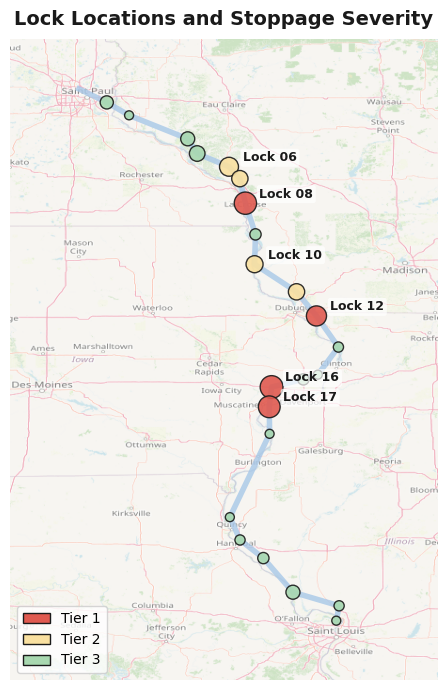

saved: fig10_lock_map_static.png


In [18]:
import urllib.request
import math
import io
from PIL import Image

lockCoords = {
    '01': (44.915, -93.193), '02': (44.757, -92.868), '03': (44.606, -92.607),
    '04': (44.331, -91.921), '05': (44.159, -91.810), '06': (44.004, -91.438),
    '07': (43.865, -91.311), '08': (43.578, -91.246), '09': (43.213, -91.128),
    '10': (42.864, -91.139), '11': (42.541, -90.648), '12': (42.259, -90.415),
    '13': (41.895, -90.158), '14': (41.572, -90.399), '15': (41.517, -90.568),
    '16': (41.427, -90.940), '17': (41.196, -90.967), '18': (40.880, -90.963),
    '21': (39.905, -91.428), '22': (39.638, -91.309), '24': (39.426, -91.036),
    '25': (39.027, -90.690), '26': (38.868, -90.150), '27': (38.694, -90.183),
}

# Fetch map tiles using pure python so we don't need kaleido
def get_osm_map(min_lat, max_lat, min_lon, max_lon, zoom=7):
    def deg2num(lat_deg, lon_deg, zoom):
        lat_rad = math.radians(lat_deg)
        n = 2.0 ** zoom
        xtile = int((lon_deg + 180.0) / 360.0 * n)
        ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
        return (xtile, ytile)
    
    xmin, ymax = deg2num(min_lat, min_lon, zoom)
    xmax, ymin = deg2num(max_lat, max_lon, zoom)
    
    # ymin/ymax inverted in OSM coordinates
    img = Image.new('RGB', ((xmax - xmin + 1) * 256, (ymax - ymin + 1) * 256))
    
    for xtile in range(xmin, xmax + 1):
        for ytile in range(ymin, ymax + 1):
            url = f"https://tile.openstreetmap.org/{zoom}/{xtile}/{ytile}.png"
            req = urllib.request.Request(url, headers={'User-Agent': 'sc-project-script/1.0'})
            try:
                with urllib.request.urlopen(req) as resp:
                    tile = Image.open(io.BytesIO(resp.read()))
                    img.paste(tile, ((xtile - xmin) * 256, (ytile - ymin) * 256))
            except Exception:
                pass
                
    def num2deg(xtile, ytile, zoom):
        n = 2.0 ** zoom
        lon_deg = xtile / n * 360.0 - 180.0
        lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
        lat_deg = math.degrees(lat_rad)
        return (lat_deg, lon_deg)
    
    extent_min_lat, extent_min_lon = num2deg(xmin, ymax + 1, zoom)
    extent_max_lat, extent_max_lon = num2deg(xmax + 1, ymin, zoom)
    return img, [extent_min_lon, extent_max_lon, extent_min_lat, extent_max_lat]

fig, ax = plt.subplots(figsize=(7, 7))

# Get Background Map
try:
    # Adding padding around the data
    map_img, map_extent = get_osm_map(38.0, 45.5, -94.0, -89.0, zoom=7)
    ax.imshow(map_img, extent=map_extent, zorder=0, alpha=0.6)
except Exception as e:
    print("Map fetch failed, falling back to blank background:", e)

mapDf = lockSummary.copy()
mapDf['lat'] = mapDf['lockNumber'].map(lambda x: lockCoords.get(x, (None, None))[0])
mapDf['lon'] = mapDf['lockNumber'].map(lambda x: lockCoords.get(x, (None, None))[1])
mapDf = mapDf.dropna(subset=['lat', 'lon'])
mapDf = mapDf.sort_values('totalHrs', ascending=False).reset_index(drop=True)

# river path
riverOrder = sorted(lockCoords.keys(), key=lambda k: lockCoords[k][0], reverse=True)
ax.plot([lockCoords[k][1] for k in riverOrder],
        [lockCoords[k][0] for k in riverOrder],
        color=PBLUE, linewidth=4, alpha=0.8, zorder=1)

colors = [DRED if i < 4 else PYELLOW if i < 8 else PGREEN for i in range(len(mapDf))]
ax.scatter(mapDf['lon'], mapDf['lat'],
           s=mapDf['totalHrs'] * 0.5 + 30, c=colors,
           edgecolors=BLACK, linewidths=1, alpha=0.9, zorder=3)

# Filter annotation to top 6 to prevent text overlap
for _, row in mapDf.head(6).iterrows():
    ax.annotate(row['lockLabel'], (row['lon'], row['lat']),
                xytext=(10, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color=BLACK,
                bbox=dict(boxstyle='round,pad=0.2', fc=WHITE, ec='none', alpha=0.7))

ax.set_xlim(-94.0, -89.0)
ax.set_ylim(38.0, 45.5)
ax.set_axis_off()

ax.set_title('Lock Locations and Stoppage Severity',
             fontsize=14, fontweight='bold', color=BLACK, pad=10)
ax.legend(handles=[
    mpatches.Patch(facecolor=DRED, edgecolor=BLACK, label='Tier 1'),
    mpatches.Patch(facecolor=PYELLOW, edgecolor=BLACK, label='Tier 2'),
    mpatches.Patch(facecolor=PGREEN, edgecolor=BLACK, label='Tier 3'),
], fontsize=10, loc='lower left')

plt.tight_layout()
plt.savefig(figDir / 'fig10_lock_map_static.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig10_lock_map_static.png')

## Slide 4: Rate Time Series (reworked fig 1)

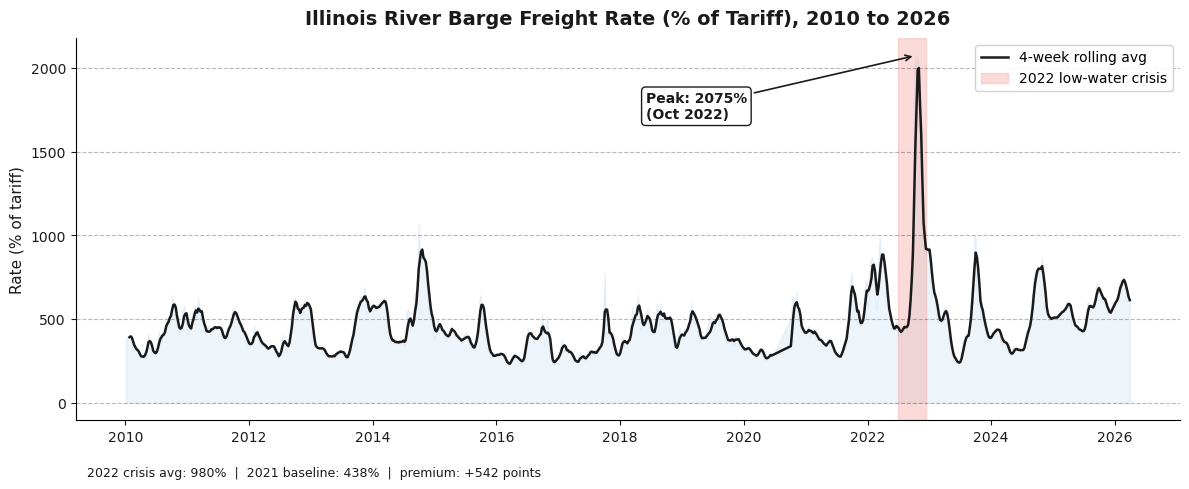

saved: fig1_rate_timeseries.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
roll = mergedDf.set_index('weekStart')['illRate'].rolling(4).mean()

ax.fill_between(mergedDf['weekStart'], mergedDf['illRate'], alpha=0.2, color=PBLUE)
ax.plot(roll.index, roll.values, color=BLACK, linewidth=1.8, label='4-week rolling avg')

# 2022 crisis shading only (2012 removed to reduce clutter)
ax.axvspan(pd.Timestamp('2022-07-01'), pd.Timestamp('2022-12-15'),
           alpha=0.4, color=PRED, label='2022 low-water crisis')

# peak annotation
peakIdx = mergedDf['illRate'].idxmax()
peakDate = mergedDf.loc[peakIdx, 'weekStart']
peakVal = mergedDf['illRate'].max()
ax.annotate(
    f'Peak: {peakVal:.0f}%\n(Oct 2022)',
    xy=(peakDate, peakVal),
    xytext=(pd.Timestamp('2018-06-01'), 1700),
    arrowprops=dict(arrowstyle='->', color=BLACK, lw=1.2),
    fontsize=10, color=BLACK, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BLACK)
)

ax.set_title('Illinois River Barge Freight Rate (% of Tariff), 2010 to 2026',
             fontsize=14, fontweight='bold', color=BLACK, pad=10)
ax.set_ylabel('Rate (% of tariff)', fontsize=11, color=BLACK)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.tick_params(labelsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--', color=BLACK)
ax.legend(fontsize=10, framealpha=0.9)

crisisAvg = crisis22['illRate'].mean()
baselineAvg = baseline21['illRate'].mean()
ax.text(0.01, -0.12,
    f'2022 crisis avg: {crisisAvg:.0f}%  |  '
    f'2021 baseline: {baselineAvg:.0f}%  |  '
    f'premium: +{crisisAvg - baselineAvg:.0f} points',
    transform=ax.transAxes, va='top', fontsize=9, color=BLACK)

plt.tight_layout()
plt.savefig(figDir / 'fig1_rate_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig1_rate_timeseries.png')

## Slide 5: 2021 vs 2022 Comparison (reworked fig 3)

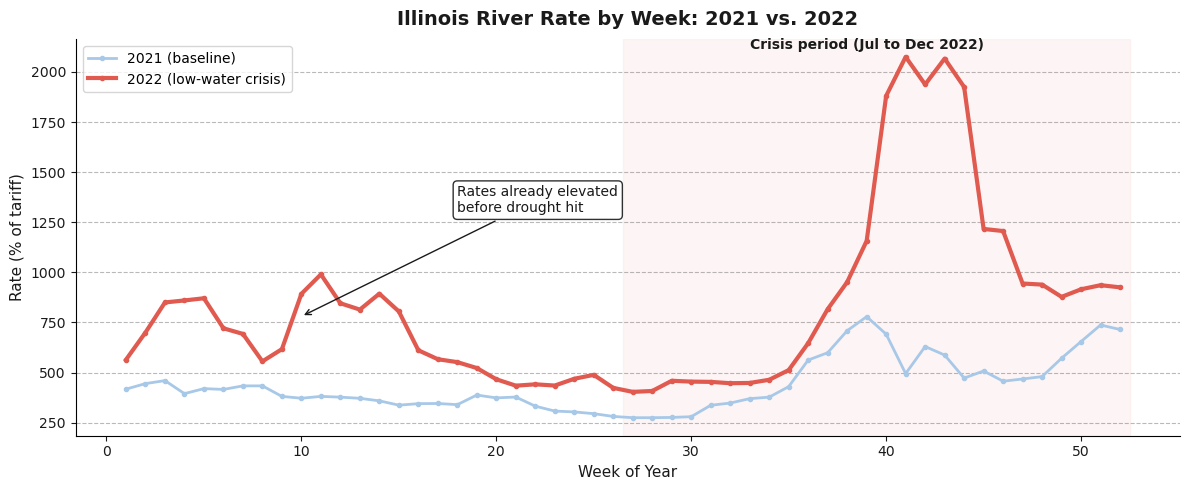

saved: fig3_2021v2022.png


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
yr21 = mergedDf[mergedDf['year'] == 2021].sort_values('week')
yr22 = mergedDf[mergedDf['year'] == 2022].sort_values('week')

ax.plot(yr21['week'], yr21['illRate'], color=PBLUE, linewidth=2,
        marker='o', markersize=3, label='2021 (baseline)')
ax.plot(yr22['week'], yr22['illRate'], color=DRED, linewidth=3,
        marker='o', markersize=3, label='2022 (low-water crisis)')
ax.axvspan(26.5, 52.5, alpha=0.10, color=PRED)

ax.text(39, yr22['illRate'].max() * 1.02,
        'Crisis period (Jul to Dec 2022)',
        ha='center', fontsize=10, color=BLACK, fontweight='bold')

# annotation: early-year elevation
earlyWeek = 10
earlyRate = yr22[yr22['week'].between(8, 12)]['illRate'].mean()
ax.annotate(
    'Rates already elevated\nbefore drought hit',
    xy=(earlyWeek, earlyRate),
    xytext=(18, 1300),
    arrowprops=dict(arrowstyle='->', color=BLACK, lw=1),
    fontsize=10, color=BLACK,
    bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BLACK, alpha=0.9)
)

ax.set_title('Illinois River Rate by Week: 2021 vs. 2022',
             fontsize=14, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Week of Year', fontsize=11)
ax.set_ylabel('Rate (% of tariff)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--', color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'fig3_2021v2022.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig3_2021v2022.png')

## Slide 6: Stoppage Causes (redesigned fig 6, single panel)

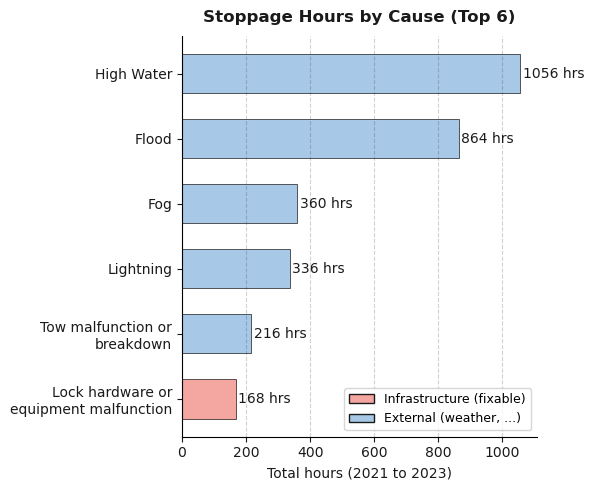

saved: fig6_stoppage_causes_v2.png


In [25]:
import textwrap

fig, ax = plt.subplots(figsize=(6, 5))

reasonHrs = unschedDf.groupby('reasonCode')['durationHrs'].sum().sort_values(ascending=True).tail(6)
# shorten long labels
labels = []
for r in reasonHrs.index:
    labels.append(textwrap.fill(r, width=25))

infraKeys = ['repair', 'hardware', 'maintain']
colors = [PRED if any(k in r.lower() for k in infraKeys) else PBLUE
          for r in reasonHrs.index]

bars = ax.barh(labels, reasonHrs.values, color=colors,
               height=0.6, edgecolor=BLACK, linewidth=0.5)

for bar, val in zip(bars, reasonHrs.values):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} hrs', va='center', fontsize=10, color=BLACK)

ax.set_title('Stoppage Hours by Cause (Top 6)',
             fontsize=12, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Total hours (2021 to 2023)', fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(axis='x', alpha=0.2, linestyle='--', color=BLACK)
ax.legend(handles=[
    mpatches.Patch(facecolor=PRED, edgecolor=BLACK, label='Infrastructure (fixable)'),
    mpatches.Patch(facecolor=PBLUE, edgecolor=BLACK, label='External (weather, ...)'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(figDir / 'fig6_stoppage_causes_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig6_stoppage_causes_v2.png')

## Slide 7: Rate Decomposition Waterfall (NEW)

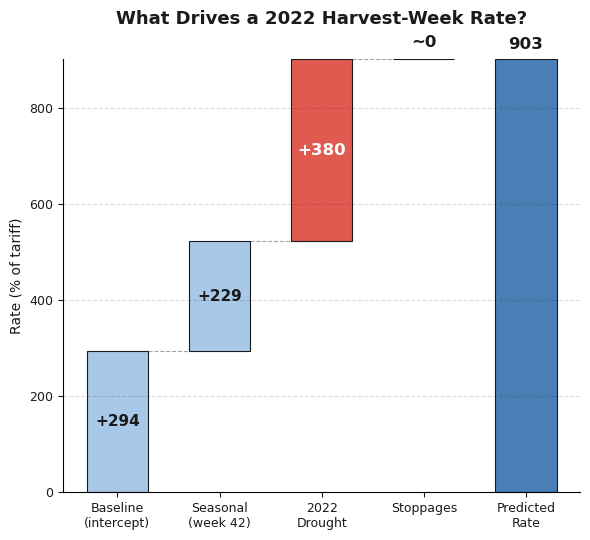

saved: fig_waterfall_decomposition.png
  intercept=294, week=229, drought=+380, stoppages=-0.1, total=903


In [28]:
# decompose predicted rate for a typical 2022 harvest week (week 42)
# coefs2: [stoppageHrs, week, yr2022, yr2023, intercept]
intercept_val = coefs2[4]
week_effect = coefs2[1] * 42
drought_effect = coefs2[2]  # 2022 dummy
avg_stop_hrs = matchedDf[matchedDf['year'] == 2022]['stoppageHrs'].mean()
stoppage_effect = coefs2[0] * avg_stop_hrs
predicted_total = intercept_val + week_effect + drought_effect + stoppage_effect

labels = ['Baseline\n(intercept)', 'Seasonal\n(week 42)', '2022\nDrought', 'Stoppages', 'Predicted\nRate']
heights = [intercept_val, week_effect, drought_effect, stoppage_effect, predicted_total]
bottoms = [0, intercept_val, intercept_val + week_effect,
           intercept_val + week_effect + drought_effect, 0]
barColors = [PBLUE, PBLUE, DRED, PGRAY, '#4a7fb5']

fig, ax = plt.subplots(figsize=(6, 5.5))
bars = ax.bar(labels, heights, bottom=bottoms, color=barColors,
              edgecolor=BLACK, linewidth=0.8, width=0.6)

# value labels
for i, (bar, h, b) in enumerate(zip(bars, heights, bottoms)):
    if i == 3:
        # stoppage bar is tiny, label above
        ax.text(bar.get_x() + bar.get_width() / 2,
                b + max(h, 0) + 18, '~0',
                ha='center', va='bottom', fontsize=12,
                fontweight='bold', color=BLACK)
    elif i == 4:
        # total bar, label on top
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 15, f'{h:.0f}',
                ha='center', va='bottom', fontsize=12,
                fontweight='bold', color=BLACK)
    elif i == 2:
        # drought bar, white text inside
        ax.text(bar.get_x() + bar.get_width() / 2,
                b + h / 2, f'+{h:.0f}',
                ha='center', va='center', fontsize=12,
                fontweight='bold', color=WHITE)
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                b + h / 2, f'+{h:.0f}',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=BLACK)

# connector lines between waterfall steps
for i in range(3):
    top = bottoms[i] + heights[i]
    ax.plot([i + 0.3, i + 0.7], [top, top],
            color=BLACK, linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_ylabel('Rate (% of tariff)', fontsize=10)
ax.set_title('What Drives a 2022 Harvest-Week Rate?',
             fontsize=13, fontweight='bold', color=BLACK, pad=25)
ax.grid(axis='y', alpha=0.15, linestyle='--', color=BLACK)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(figDir / 'fig_waterfall_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig_waterfall_decomposition.png')
print(f'  intercept={intercept_val:.0f}, week={week_effect:.0f}, '
      f'drought=+{drought_effect:.0f}, stoppages={stoppage_effect:.1f}, '
      f'total={predicted_total:.0f}')

## Slide 8: Lock Stoppage Hours, Top 6 (reworked fig 5)

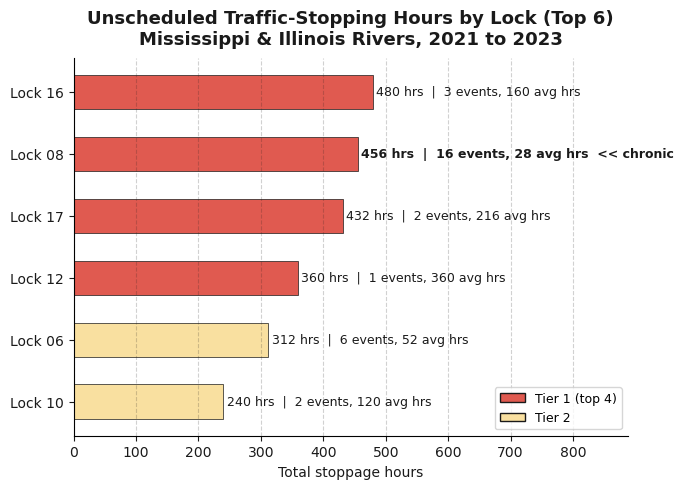

saved: fig5_lock_hours_v2.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
top6 = lockSummary.head(6).iloc[::-1]  # reverse so highest is at top of barh

barColors = []
for i in range(len(top6)):
    rank = len(top6) - i  # rank 1 = most hours (top bar)
    barColors.append(DRED if rank <= 4 else PYELLOW)

bars = ax.barh(top6['lockLabel'], top6['totalHrs'], color=barColors,
               height=0.55, edgecolor=BLACK, linewidth=0.5)

for bar, (_, row) in zip(bars, top6.iterrows()):
    chronic = '  << chronic' if row['lockNumber'] == '08' else ''
    txt = (f'{row["totalHrs"]:.0f} hrs  |  '
           f'{row["numStoppages"]:.0f} events, '
           f'{row["avgHrs"]:.0f} avg hrs'
           f'{chronic}')
    weight = 'bold' if row['lockNumber'] == '08' else 'normal'
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            txt, va='center', fontsize=9, color=BLACK, fontweight=weight)

ax.set_title('Unscheduled Traffic-Stopping Hours by Lock (Top 6)\n'
             'Mississippi & Illinois Rivers, 2021 to 2023',
             fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Total stoppage hours', fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(axis='x', alpha=0.2, linestyle='--', color=BLACK)
ax.set_xlim(0, top6['totalHrs'].max() * 1.85)  # room for annotations
ax.legend(handles=[
    mpatches.Patch(facecolor=DRED, edgecolor=BLACK, label='Tier 1 (top 4)'),
    mpatches.Patch(facecolor=PYELLOW, edgecolor=BLACK, label='Tier 2'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(figDir / 'fig5_lock_hours_v2.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig5_lock_hours_v2.png')

## Slide 9: Pareto / Cumulative Concentration Chart (NEW)

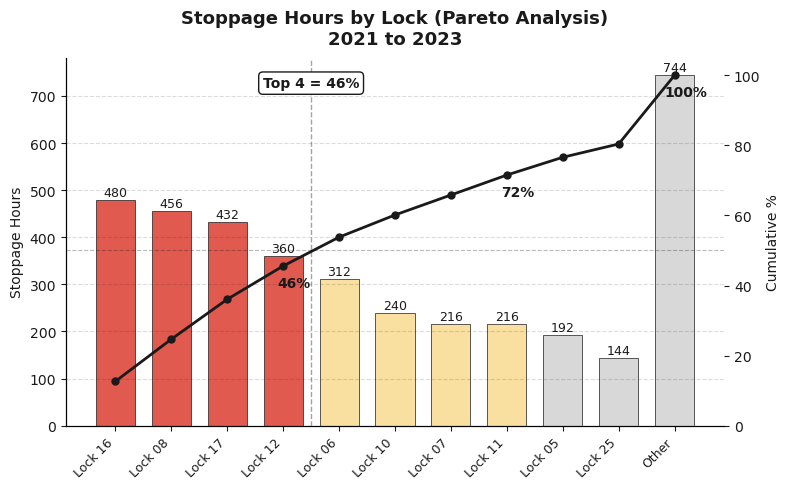

saved: fig_pareto_locks.png


In [33]:
paretoDf = lockSummary.sort_values('totalHrs', ascending=False).reset_index(drop=True)
paretoDf['cumPct'] = paretoDf['totalHrs'].cumsum() / totalSystemHrs * 100

# show top 10 individually, group remainder as "Other"
topN = min(10, len(paretoDf))
showDf = paretoDf.head(topN).copy()
otherHrs = paretoDf.iloc[topN:]['totalHrs'].sum() if len(paretoDf) > topN else 0
if otherHrs > 0:
    otherRow = pd.DataFrame({
        'lockLabel': ['Other'],
        'totalHrs': [otherHrs],
    })
    showDf = pd.concat([showDf, otherRow], ignore_index=True)

showDf['cumPct'] = showDf['totalHrs'].cumsum() / totalSystemHrs * 100

barColors = []
for i in range(len(showDf)):
    if i < 4:
        barColors.append(DRED)
    elif i < 8:
        barColors.append(PYELLOW)
    else:
        barColors.append(PGRAY)

fig, ax1 = plt.subplots(figsize=(8, 5))
x = range(len(showDf))
bars = ax1.bar(x, showDf['totalHrs'], color=barColors,
               edgecolor=BLACK, linewidth=0.5, width=0.7)

for bar, val in zip(bars, showDf['totalHrs']):
    if val > 40:
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8,
                 f'{val:.0f}', ha='center', fontsize=9, color=BLACK)

ax1.set_xticks(list(x))
ax1.set_xticklabels(showDf['lockLabel'], fontsize=9, rotation=45, ha='right')
ax1.set_ylabel('Stoppage Hours', fontsize=10)

# cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.plot(list(x), showDf['cumPct'].values, color=BLACK,
         marker='o', markersize=5, linewidth=2, zorder=5)
ax2.set_ylabel('Cumulative %', fontsize=10)
ax2.set_ylim(0, 105)

# add % labels on the cumulative line
for xi, pct in zip(x, showDf['cumPct']):
    if xi in [3, 7, len(showDf) - 1]:
        ax2.text(xi+0.2, pct - 6, f'{pct:.0f}%', ha='center',
                 fontsize=10, fontweight='bold', color=BLACK)

# 50% reference line
ax2.axhline(50, color=BLACK, linestyle='--', linewidth=0.8, alpha=0.3)

# vertical separator after top 4
ax1.axvline(3.5, color=BLACK, linestyle='--', linewidth=1, alpha=0.4)
top4pct = showDf['cumPct'].iloc[3]
ax1.text(3.5, ax1.get_ylim()[1] * 0.92,
         f'Top 4 = {top4pct:.0f}%',
         ha='center', fontsize=10, fontweight='bold', color=BLACK,
         bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BLACK))

ax1.set_title('Stoppage Hours by Lock (Pareto Analysis)\n'
              '2021 to 2023',
              fontsize=13, fontweight='bold', color=BLACK, pad=10)
ax1.grid(axis='y', alpha=0.15, linestyle='--', color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'fig_pareto_locks.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: fig_pareto_locks.png')

## Appendix Figures

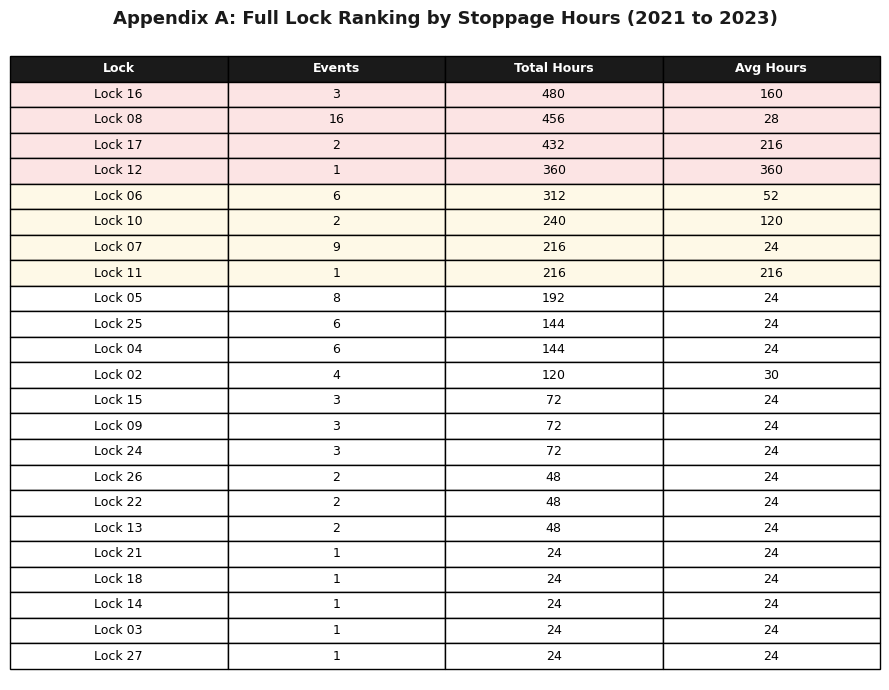

saved: appendix_a_lock_table.png


In [12]:
# --- Appendix A: Full Lock Ranking Table ---
fig, ax = plt.subplots(figsize=(9, 7))
ax.axis('off')

tableDf = lockSummary[['lockLabel', 'numStoppages', 'totalHrs', 'avgHrs']].copy()
tableDf.columns = ['Lock', 'Events', 'Total Hours', 'Avg Hours']
tableDf['Total Hours'] = tableDf['Total Hours'].apply(lambda x: f'{x:.0f}')
tableDf['Avg Hours'] = tableDf['Avg Hours'].apply(lambda x: f'{x:.0f}')
tableDf['Events'] = tableDf['Events'].astype(int)

table = ax.table(
    cellText=tableDf.values,
    colLabels=tableDf.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

# style header row
for j in range(len(tableDf.columns)):
    table[0, j].set_facecolor(BLACK)
    table[0, j].set_text_props(color=WHITE, fontweight='bold')

# tier colors for data rows
for i in range(1, len(tableDf) + 1):
    for j in range(len(tableDf.columns)):
        if i <= 4:
            table[i, j].set_facecolor('#fce4e4')
        elif i <= 8:
            table[i, j].set_facecolor('#fef9e7')
        else:
            table[i, j].set_facecolor(WHITE)

ax.set_title('Appendix A: Full Lock Ranking by Stoppage Hours (2021 to 2023)',
             fontsize=13, fontweight='bold', color=BLACK, pad=15)
plt.tight_layout()
plt.savefig(figDir / 'appendix_a_lock_table.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: appendix_a_lock_table.png')

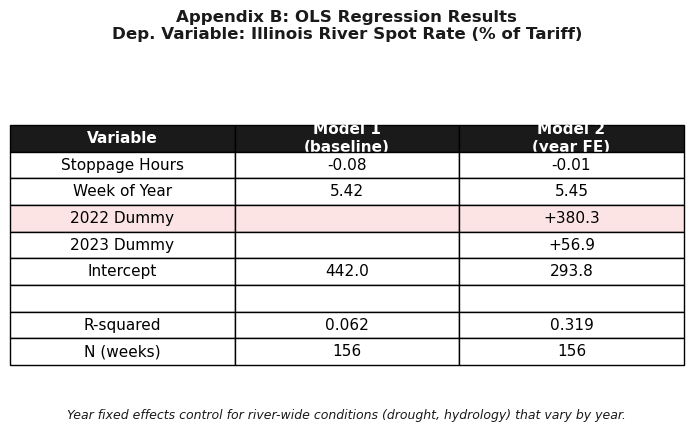

saved: appendix_b_regression.png


In [13]:
# --- Appendix B: Regression Details Table ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axis('off')

regData = [
    ['Stoppage Hours', f'{coefs1[0]:.2f}', f'{coefs2[0]:.2f}'],
    ['Week of Year', f'{coefs1[1]:.2f}', f'{coefs2[1]:.2f}'],
    ['2022 Dummy', '', f'+{coefs2[2]:.1f}'],
    ['2023 Dummy', '', f'+{coefs2[3]:.1f}'],
    ['Intercept', f'{coefs1[2]:.1f}', f'{coefs2[4]:.1f}'],
    ['', '', ''],
    ['R-squared', f'{r2_1:.3f}', f'{r2_2:.3f}'],
    ['N (weeks)', str(len(regDf)), str(len(regDf))],
]

table = ax.table(
    cellText=regData,
    colLabels=['Variable', 'Model 1\n(baseline)', 'Model 2\n(year FE)'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

for j in range(3):
    table[0, j].set_facecolor(BLACK)
    table[0, j].set_text_props(color=WHITE, fontweight='bold')

# highlight 2022 dummy row
for j in range(3):
    table[3, j].set_facecolor('#fce4e4')

ax.set_title('Appendix B: OLS Regression Results\n'
             'Dep. Variable: Illinois River Spot Rate (% of Tariff)',
             fontsize=12, fontweight='bold', color=BLACK, pad=15)

ax.text(0.5, 0.03,
    'Year fixed effects control for river-wide conditions '
    '(drought, hydrology) that vary by year.',
    transform=ax.transAxes, ha='center', fontsize=9,
    color=BLACK, style='italic')

plt.tight_layout()
plt.savefig(figDir / 'appendix_b_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: appendix_b_regression.png')

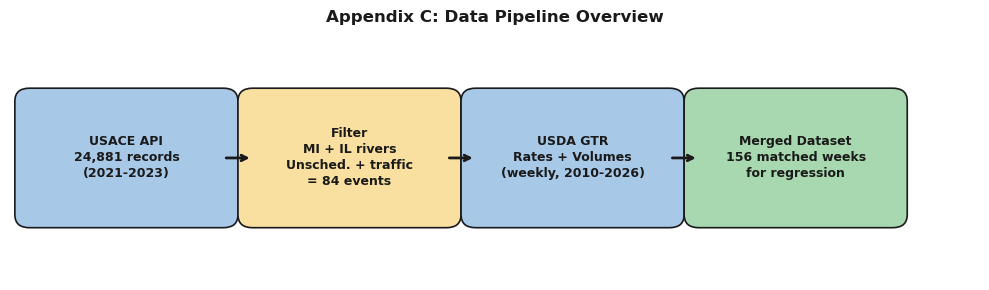

saved: appendix_c_pipeline.png


In [14]:
# --- Appendix C: Data Pipeline Diagram ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 2.8)

boxes = [
    (1.2, 1.4, 'USACE API\n24,881 records\n(2021-2023)', PBLUE),
    (3.5, 1.4, 'Filter\nMI + IL rivers\nUnsched. + traffic\n= 84 events', PYELLOW),
    (5.8, 1.4, 'USDA GTR\nRates + Volumes\n(weekly, 2010-2026)', PBLUE),
    (8.1, 1.4, 'Merged Dataset\n156 matched weeks\nfor regression', PGREEN),
]

for cx, cy, text, color in boxes:
    rect = mpatches.FancyBboxPatch(
        (cx - 1.0, cy - 0.65), 2.0, 1.3,
        boxstyle='round,pad=0.15', facecolor=color,
        edgecolor=BLACK, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=9, color=BLACK, fontweight='bold',
            linespacing=1.3)

# arrows between boxes
for x1, x2 in [(2.2, 2.5), (4.5, 4.8), (6.8, 7.1)]:
    ax.annotate('', xy=(x2, 1.4), xytext=(x1, 1.4),
                arrowprops=dict(arrowstyle='->', color=BLACK, lw=2))

ax.set_title('Appendix C: Data Pipeline Overview',
             fontsize=12, fontweight='bold', color=BLACK, pad=10)
plt.tight_layout()
plt.savefig(figDir / 'appendix_c_pipeline.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: appendix_c_pipeline.png')

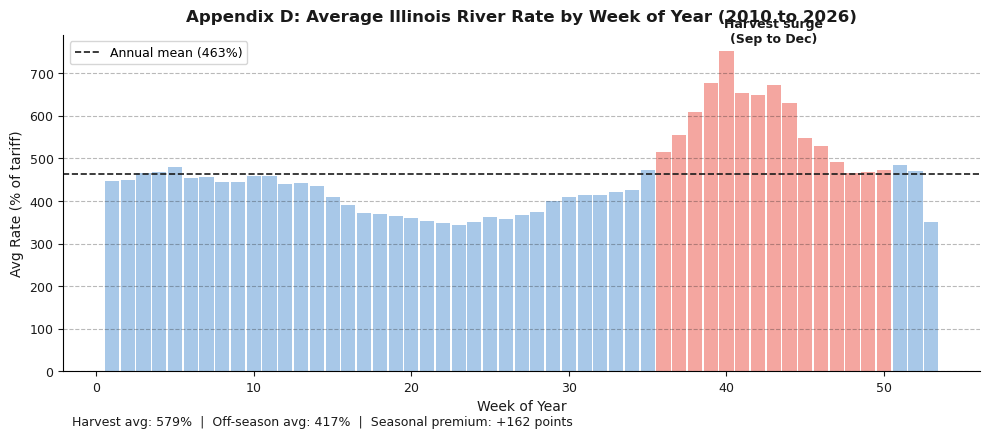

saved: appendix_d_seasonal.png


In [15]:
# --- Appendix D: Seasonal Pattern ---
fig, ax = plt.subplots(figsize=(10, 4.5))
seasonal = mergedDf.groupby('week')['illRate'].mean()

barColors = [PRED if 36 <= w <= 50 else PBLUE for w in seasonal.index]
ax.bar(seasonal.index, seasonal.values, color=barColors, width=0.9, edgecolor='none')
ax.axhline(mergedDf['illRate'].mean(), color=BLACK, linestyle='--', linewidth=1.2,
           label=f'Annual mean ({mergedDf["illRate"].mean():.0f}%)')

ax.text(43, seasonal.loc[36:50].max() + 20,
        'Harvest surge\n(Sep to Dec)',
        ha='center', fontsize=9, color=BLACK, fontweight='bold')

ax.set_title('Appendix D: Average Illinois River Rate by Week of Year (2010 to 2026)',
             fontsize=12, fontweight='bold', color=BLACK, pad=10)
ax.set_xlabel('Week of Year', fontsize=10)
ax.set_ylabel('Avg Rate (% of tariff)', fontsize=10)
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--', color=BLACK)
ax.text(0.01, -0.13,
    f'Harvest avg: {harvestAvg:.0f}%  |  '
    f'Off-season avg: {offseasonAvg:.0f}%  |  '
    f'Seasonal premium: +{harvestAvg - offseasonAvg:.0f} points',
    transform=ax.transAxes, va='top', fontsize=9, color=BLACK)
plt.tight_layout()
plt.savefig(figDir / 'appendix_d_seasonal.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: appendix_d_seasonal.png')

In [16]:
# summary of all saved figures
print('=== All presentation figures ===')
print()
for f in sorted(figDir.glob('*')):
    print(f'  {f.name}')

=== All presentation figures ===

  appendix_a_lock_table.png
  appendix_b_regression.png
  appendix_c_pipeline.png
  appendix_d_seasonal.png
  fig10_lock_map.html
  fig1_rate_timeseries.png
  fig3_2021v2022.png
  fig5_lock_hours_v2.png
  fig6_stoppage_causes_v2.png
  fig_pareto_locks.png
  fig_waterfall_decomposition.png
